# Week 15-2 · OTS-02 — Volatility Trading &amp; Variance Premium

**Instructor: Varun Kumar Potra** (11 yrs quant; options trader, global-macro analyst, algo strategist).
The second options session — a *foundation* lecture that clears the mental blocks before the real
machinery of OTS-3 to OTS-6. The lecture ships no code; this notebook turns every claim into runnable
Python.

**The arc of the lecture:**

| Theme | The idea |
|---|---|
| Two ways to find edge | **model-driven** (continuous, scalable) vs **event-driven** (earnings/rates, rare) |
| The trader's bar | you don't need 90% accuracy — a **t-stat of 1** (≈55%) is tradable |
| What eats the edge | **adverse selection** (good trades don't fill) + **costs** (bid-ask, fees) |
| Why options exist | **volatility** is predictable; *direction* is not (Sharpe's quote) |
| Payoffs | call, put, and the **straddle** — the foundation of volatility trading |
| Volatility's 3 laws | negatively correlated to returns · vol-of-vol · **mean-reverting** |
| IV vs HV | implied (forward, from price) vs historical (backward, from returns) → the **smile** |
| The payday | **variance premium** = IV − RV, the gap you harvest (and why naive selling fails) |

The thesis in one line: *you make money in options not by predicting price, but by trading the gap
between the volatility the market **expects** and the volatility that actually **happens**.*

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
print("ready")

ready


## Model-driven vs event-driven — and the trader's bar

A **model** spits out a number every day (Black-Scholes says fair value is \$2, market is \$4 → don't
buy). An **event** strategy fires only on a trigger (earnings, rate decision). Models **scale** (run on
500 names, more capital); events are rare (earnings ~4×/yr) and hard to scale. Pros run a model daily
*and* deploy event strategies when the calendar lights up.

The mindset shift: a **researcher** wants a *t-stat of 2* (p &lt; 0.05). A **trader** only needs a
*t-stat of 1* — just reliably better than a coin flip.

In [2]:
# A 55% directional edge is small but, compounded over many independent bets, decisively non-random.
p = 0.55                      # win probability per trade
for n in [10, 100, 1000]:
    se = np.sqrt(p*(1-p)/n)   # standard error of the win-rate estimate
    t = (p - 0.50)/se         # t-stat vs a coin flip
    print(f"n={n:5d} trades: win-rate {p:.0%}, t-stat vs 50% = {t:.2f}")
print("\nResearcher demands t>2; a trader is happy at t~1. 55% is NOT 'almost random' once you")
print("get the trade count up. You don't need 90% accuracy - you need a small edge, many times.")

n=   10 trades: win-rate 55%, t-stat vs 50% = 0.32
n=  100 trades: win-rate 55%, t-stat vs 50% = 1.01
n= 1000 trades: win-rate 55%, t-stat vs 50% = 3.18

Researcher demands t>2; a trader is happy at t~1. 55% is NOT 'almost random' once you
get the trade count up. You don't need 90% accuracy - you need a small edge, many times.


## Adverse selection — why a beautiful backtest dies live

The single most important trap in the lecture. When you place a limit buy at \$100 and get **filled
instantly**, the counterparty was *happy to sell to you at 100* — often because you're on the wrong
side. The trades that would have been **profitable** sit at extreme prices and **never fill**; the
**losing** trades fill easily. A backtest assumes every order fills, so it counts the winners you'd
never actually get.

In [3]:
# Backtest: every signal 'fills'. Live: winners sit at extreme prices and miss; losers fill.
rng = np.random.default_rng(152)
n = 1000
pnl = rng.normal(2.0, 25.0, n)          # per-trade P&L the BACKTEST sees (slight positive edge)

# Live fill probability is LOWER for the best trades (adverse selection):
# the more profitable the trade looks, the less likely you get the fill.
rank = (pnl - pnl.min())/(pnl.max()-pnl.min())     # 0..1, high = very profitable
fill_prob = 0.85 - 0.6*rank                          # winners ~25% fill, losers ~85% fill
filled = rng.random(n) < fill_prob

bt = pnl.mean()                          # backtest average (all fills)
live = pnl[filled].mean()                # live average (only what actually filled)
print(f"Backtest avg P&L/trade (all fill) : {bt:+.2f}")
print(f"Live avg P&L/trade (adverse fill) : {live:+.2f}")
print(f"Edge destroyed by adverse selection: {bt-live:+.2f} per trade")
print("Fix: take ALL the trades (don't cherry-pick fills) - but that raises costs. The tension is real.")

Backtest avg P&L/trade (all fill) : +3.04
Live avg P&L/trade (adverse fill) : -0.76
Edge destroyed by adverse selection: +3.81 per trade
Fix: take ALL the trades (don't cherry-pick fills) - but that raises costs. The tension is real.


### Costs — the second silent killer
A profitable gross strategy often dies after costs: **bid-ask spread** (you wanted 100, you pay 102),
**brokerage, taxes, platform/exchange fees**. Varun's rule of thumb: ~20-30% of gross profit gone, and
**~80% of 'profitable' backtests become worthless** once costs are in. A student's example: a Sharpe of
1.45 went to a CAGR of **−2** after transaction costs. (Leverage *increases* costs — don't use it to
'save capital'.)

In [4]:
# Same gross edge, escalating cost per round-trip -> net edge flips negative fast.
gross_per_trade = 2.0
for cost in [0.0, 0.5, 1.0, 2.0, 3.0]:
    net = gross_per_trade - cost
    print(f"cost ${cost:.1f}/round-trip -> net ${net:+.2f}/trade  {'(dead)' if net<=0 else ''}")
print("\nAlways subtract costs INSIDE the backtest. Be aggressive entering momentum (pay up to get in),")
print("passive when hedging (save the spread). 'Sharpe 1.45 gross -> CAGR -2 net' is the cautionary tale.")

cost $0.0/round-trip -> net $+2.00/trade  
cost $0.5/round-trip -> net $+1.50/trade  
cost $1.0/round-trip -> net $+1.00/trade  
cost $2.0/round-trip -> net $+0.00/trade  (dead)
cost $3.0/round-trip -> net $-1.00/trade  (dead)

Always subtract costs INSIDE the backtest. Be aggressive entering momentum (pay up to get in),
passive when hedging (save the spread). 'Sharpe 1.45 gross -> CAGR -2 net' is the cautionary tale.


## Why options = volatility (Sharpe's quote)

> *"For predicting future values, historical data appear quite useful with respect to standard
> deviation, and virtually useless for expected returns."* — William Sharpe

You cannot reliably predict *where* a stock lands, but you *can* predict **how bumpy** the path will be.
Decompose any price series into a **trend** (mean) and **volatility** (deviation around it). Options let
you trade the second part.

In [5]:
# Build a 2021-style 'SPY' path: a gentle uptrend wrapped in real volatility.
rng2 = np.random.default_rng(2021)
T = 252
drift = 0.001                              # avg daily return ~0.1% (the lecture's 0.1)
vol   = 0.008                              # daily vol ~0.8% (the lecture's 0.8)
rets = rng2.normal(drift, vol, T)
price = 370*np.exp(np.cumsum(rets))        # starts ~370, drifts toward ~470
ma = pd.Series(price).rolling(30).mean()
print(f"avg daily return = {rets.mean()*100:.2f}%   daily vol = {rets.std()*100:.2f}%")
print(f"price {price[0]:.0f} -> {price[-1]:.0f} (+{price[-1]/price[0]-1:.0%}) but the PATH is bumpy:")
print(f"  realized annualized vol = {rets.std()*np.sqrt(252)*100:.1f}%")
print("Trend (30d MA) is easy to see; the wiggle around it is the volatility we actually trade.")

avg daily return = 0.09%   daily vol = 0.79%
price 370 -> 468 (+26%) but the PATH is bumpy:
  realized annualized vol = 12.6%
Trend (30d MA) is easy to see; the wiggle around it is the volatility we actually trade.


## Payoffs — call, put, straddle (payoff is NOT P&L)

The contract math: a **call** pays $\max(S-X,0)$, a **put** pays $\max(X-S,0)$. **Payoff is gross** —
subtract the premium to get profit. The **straddle** (ATM call + ATM put) is the foundation of
volatility trading: it profits on a *big move in either direction* and loses only if the stock pins the
strike. It's a bet on volatility, not direction.

In [6]:
X = 100.0
S = np.linspace(60, 140, 81)
call_payoff = np.maximum(S - X, 0)
put_payoff  = np.maximum(X - S, 0)
call_prem, put_prem = 5.0, 5.0
straddle_pnl = (call_payoff - call_prem) + (put_payoff - put_prem)   # cost = both premiums = 10
# breakevens
lo, hi = X - (call_prem+put_prem), X + (call_prem+put_prem)
print(f"Call payoff at S=120: {np.maximum(120-X,0):.0f}  (profit = {np.maximum(120-X,0)-call_prem:.0f} after ${call_prem:.0f} premium)")
print(f"Straddle costs ${call_prem+put_prem:.0f}; profits only outside [{lo:.0f}, {hi:.0f}] -> needs a BIG move either way.")
print("Pinned at the strike (S=100) -> straddle loses the full premium. It's a long-volatility bet.")

Call payoff at S=120: 20  (profit = 15 after $5 premium)
Straddle costs $10; profits only outside [90, 110] -> needs a BIG move either way.
Pinned at the strike (S=100) -> straddle loses the full premium. It's a long-volatility bet.


## Volatility's three laws

### Law 1 — vol is negatively correlated to equity-index returns
When stocks fall, fear (and VIX) spikes; when they rise, vol drifts down. The lecture cites ≈ **−0.7**
across daily/weekly/monthly for SPX vs VIX. (Commodities differ: energy negative, but **gold is
positive** — a safe-haven that rallies *and* gets volatile in a crisis.)

In [7]:
# Construct SPX returns and a VIX-like series that rises when returns fall.
rng3 = np.random.default_rng(7)
spx_ret = rng3.normal(0.0004, 0.011, 1500)
vix = 18 - 600*spx_ret + rng3.normal(0, 6.7, 1500)     # falls with up-days, jumps on down-days
vix = np.clip(vix, 9, 80)
corr = np.corrcoef(spx_ret, vix)[0,1]
print(f"corr(SPX returns, VIX) = {corr:.2f}   (lecture: ~ -0.7 across timeframes)")
print("Use it as a regime gauge: market falling AND vol low = an abnormal regime worth investigating.")

corr(SPX returns, VIX) = -0.68   (lecture: ~ -0.7 across timeframes)
Use it as a regime gauge: market falling AND vol low = an abnormal regime worth investigating.


### Law 2 — vol-of-vol: high vol means vol itself moves a lot
Volatility of volatility (think VVIX). The lecture cites a positive correlation ≈ **0.8** between the
*level* of vol and the *size of its changes*. Practical reading: in a **low-vol** regime vol rarely
spikes suddenly; in a **high-vol** regime a vol **crash** is very likely (mean reversion from the top).

In [8]:
# Vol-of-vol: in high-vol regimes the vol series itself is MORE variable (GARCH-like clustering).
# Measure vol LEVEL = 21d rolling mean, and VOL-OF-VOL = 21d rolling std, then correlate (as the lecture does).
rng_vv = np.random.default_rng(33)
vv = np.empty(2000); vv[0] = 18.0
for i in range(1, 2000):
    step = rng_vv.normal(0, 0.11*vv[i-1])          # variability scales with level
    vv[i] = max(6.0, vv[i-1] + step - 0.02*(vv[i-1]-18))   # weak mean-revert to 18 -> wide regimes
vs = pd.Series(vv)
level   = vs.rolling(21).mean()                    # the vol LEVEL
volofvol = vs.rolling(21).std()                    # VOL-OF-VOL = how variable vol is
c = level.corr(volofvol)
print(f"corr(vol LEVEL, vol-of-vol) = {c:.2f}   (lecture: ~ +0.8)")
print("Low vol -> small changes (vol won't suddenly explode). High vol -> big changes (a crash is likely).")

corr(vol LEVEL, vol-of-vol) = 0.70   (lecture: ~ +0.8)
Low vol -> small changes (vol won't suddenly explode). High vol -> big changes (a crash is likely).


### Law 3 — vol is mean-reverting (price is not)
A price series trends — its moving average hugs and follows it. VIX does **not** trend; it oscillates
around a stable mean, going above and snapping back. Autocorrelation of VIX is weakly negative daily
but stronger weekly/monthly (the lecture: ~51% daily vs ~60% monthly sign-flip).

In [9]:
# An AR(1) mean-reverting VIX vs a trending price - compare distance-from-mean behavior.
rng4 = np.random.default_rng(11)
mu, kappa = 18.0, 0.06
v = np.empty(800); v[0] = 30.0
for i in range(1, 800):
    v[i] = v[i-1] + kappa*(mu - v[i-1]) + rng4.normal(0, 1.4)   # pull back toward mu
ac1 = np.corrcoef(v[:-1], v[1:])[0,1]
# sign-flip frequency (mean-reversion signature) at daily vs ~monthly horizon
flip_d = np.mean(np.sign(np.diff(v)[:-1]) != np.sign(np.diff(v)[1:]))
flip_m = np.mean(np.sign(np.diff(v[::21])[:-1]) != np.sign(np.diff(v[::21])[1:]))
print(f"VIX-like AR(1): lag-1 autocorr = {ac1:.2f} (persistent level), reverts to mean {mu:.0f}")
print(f"sign-flip freq daily = {flip_d:.0%}  vs ~monthly = {flip_m:.0%} (reversion clearer at longer horizon)")
print("High VIX -> bet on a crash back to mean; low VIX -> it won't spike for no reason.")

VIX-like AR(1): lag-1 autocorr = 0.92 (persistent level), reverts to mean 18
sign-flip freq daily = 53%  vs ~monthly = 65% (reversion clearer at longer horizon)
High VIX -> bet on a crash back to mean; low VIX -> it won't spike for no reason.


## Implied vs historical volatility, and the smile

**Historical vol** is backward-looking: the std of past underlying returns — every analyst computes the
*same* number. **Implied vol** is forward-looking: it's backed *out of the option's market price* via
Black-Scholes, so it reflects what traders *expect* — and everyone disagrees. Invert BSM: price → IV.

In [10]:
def bsm_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def implied_vol(price, S, K, T, r):
    # solve bsm_call(sigma) = market price for sigma
    return brentq(lambda s: bsm_call(S, K, T, r, s) - price, 1e-4, 5.0)

S0, K, Tm, r = 100, 100, 0.25, 0.04
true_sigma = 0.20
mkt = bsm_call(S0, K, Tm, r, true_sigma)
iv = implied_vol(mkt, S0, K, Tm, r)
print(f"Historical vol (input)  = {true_sigma:.1%}  -> BSM price = ${mkt:.3f}")
print(f"Invert the price -> Implied vol = {iv:.1%} (recovers the input)")
print("In the market the option trades RICHER than BSM-fair, so IV > HV. That gap is the whole game.")

Historical vol (input)  = 20.0%  -> BSM price = $4.485
Invert the price -> Implied vol = 20.0% (recovers the input)
In the market the option trades RICHER than BSM-fair, so IV > HV. That gap is the whole game.


### The volatility smile
There is **no single IV** — it changes with strike (the *smile/skew*) and with expiry (the *term
structure*). OTM puts trade rich (crash insurance + leverage effect), so IV rises away from the money.

In [11]:
# Build a smile: market prices that imply higher vol for OTM strikes.
strikes = np.array([80, 90, 95, 100, 105, 110, 120])
# a realistic skewed smile: low puts richest
smile_iv = np.array([0.30, 0.255, 0.235, 0.22, 0.225, 0.235, 0.255])
prices = [bsm_call(S0, k, Tm, r, s) for k, s in zip(strikes, smile_iv)]
recovered = [implied_vol(px, S0, k, Tm, r) for px, k in zip(prices, strikes)]
tbl = pd.DataFrame({"strike": strikes, "IV used": smile_iv, "IV recovered": np.round(recovered,3)})
print(tbl.to_string(index=False))
print(f"\nATM (K=100) IV = {smile_iv[3]:.1%} is the LOW point; OTM put (K=80) IV = {smile_iv[0]:.1%} (richest).")
print("Shape gives strategy: where the smile is cheap/rich tells you which strike to buy or sell.")

 strike  IV used  IV recovered
     80    0.300         0.300
     90    0.255         0.255
     95    0.235         0.235
    100    0.220         0.220
    105    0.225         0.225
    110    0.235         0.235
    120    0.255         0.255

ATM (K=100) IV = 22.0% is the LOW point; OTM put (K=80) IV = 30.0% (richest).
Shape gives strategy: where the smile is cheap/rich tells you which strike to buy or sell.


## The payday — variance (volatility) premium

The core profit engine: **implied vol is almost always higher than the volatility that actually
happens** (realized vol). Why? Options are **insurance** — people pay up for crash protection, so
sellers earn a premium. **Variance premium = IV − RV**. You harvest it by *selling* options when IV is
rich and letting realized vol come in lower.

In [12]:
# Simulate a year of implied vol sitting above realized vol (with occasional inversions).
rng5 = np.random.default_rng(2015)
days = 252
realized = np.clip(0.14 + 0.04*np.sin(np.linspace(0, 6, days)) + rng5.normal(0,0.02,days), 0.05, 0.6)
implied  = realized + 0.035 + rng5.normal(0, 0.015, days)   # IV usually ABOVE RV (the premium)
implied  = np.clip(implied, 0.05, 0.7)
vrp = implied - realized
print(f"Mean implied vol  = {implied.mean():.1%}")
print(f"Mean realized vol = {realized.mean():.1%}")
print(f"Mean variance premium (IV-RV) = {vrp.mean()*100:.1f} vol points  (positive {np.mean(vrp>0):.0%} of days)")
print(f"Days IV < RV (premium INVERTS, sellers lose) = {np.sum(vrp<0)} / {days}")
print("Sell vol when the premium is fat; but it inverts in shocks - that's the tail you must respect.")

Mean implied vol  = 17.5%
Mean realized vol = 13.9%
Mean variance premium (IV-RV) = 3.5 vol points  (positive 99% of days)
Days IV < RV (premium INVERTS, sellers lose) = 2 / 252
Sell vol when the premium is fat; but it inverts in shocks - that's the tail you must respect.


### Counter-intuitive: low VIX → bigger variance premium
You'd think a wild market offers the richest premium. The lecture's three-decade observation is the
opposite: **when VIX is low, IV−RV (in percentage terms) tends to be largest** — more harvesting
opportunity in calm regimes.

In [13]:
# Bucket days by VIX level; show the premium is proportionally larger in low-vol buckets.
vix_proxy = implied*100
bucket = pd.cut(vix_proxy, [0,15,20,30,100], labels=["<15 (low)","15-20","20-30",">30 (high)"])
g = pd.DataFrame({"vix": vix_proxy, "vrp_pct": vrp/realized}).groupby(bucket, observed=True)["vrp_pct"].mean()
print("Avg variance premium as a FRACTION of realized vol, by VIX bucket:")
print((g*100).round(1).astype(str) + "%")
print("\nLow-VIX regimes show the largest proportional premium -> more opportunity when markets are calm.")

Avg variance premium as a FRACTION of realized vol, by VIX bucket:
<15 (low)    31.0%
15-20        27.5%
20-30        22.2%
Name: vrp_pct, dtype: str

Low-VIX regimes show the largest proportional premium -> more opportunity when markets are calm.


### Why naive 'sell a straddle every day' fails
Selling the premium daily *looks* glorious in a backtest — a smooth rising equity curve. But it carries
**fat left-tail drawdowns** (margin calls force you out at the worst time) and **costs** the chart
ignores. Harvesting the premium is right; doing it blindly is how vol sellers blow up.

In [14]:
# Daily short-straddle P&L = collect premium (IV) minus what realized vol actually costs you.
rng6 = np.random.default_rng(99)
daily_credit = implied/np.sqrt(252)                 # premium collected, scaled to daily
daily_cost   = np.abs(rng6.normal(0, realized/np.sqrt(252)))  # |move| you pay out
# occasional vol spike days inflict large losses (the tail)
spike = rng6.random(days) < 0.04
daily_cost[spike] *= 6.0
pnl = (daily_credit - daily_cost) * 1_000_000        # on a $1m notional
equity = 200_000 + np.cumsum(pnl)
peak = np.maximum.accumulate(equity)
maxdd = ((equity - peak)/peak).min()
print(f"Naive short-straddle: ending equity ${equity[-1]:,.0f} from ${equity[0]:,.0f}")
print(f"BUT max drawdown = {maxdd:.0%} (margin-call territory) on {spike.sum()} vol-spike days")
print("Smooth-looking curve, brutal tail. Sell premium SELECTIVELY (rich IV, defined risk), net of costs.")

Naive short-straddle: ending equity $683,520 from $209,312
BUT max drawdown = -20% (margin-call territory) on 15 vol-spike days
Smooth-looking curve, brutal tail. Sell premium SELECTIVELY (rich IV, defined risk), net of costs.


## Summary chart — the four ideas that pay

saved chart_1_vol.png


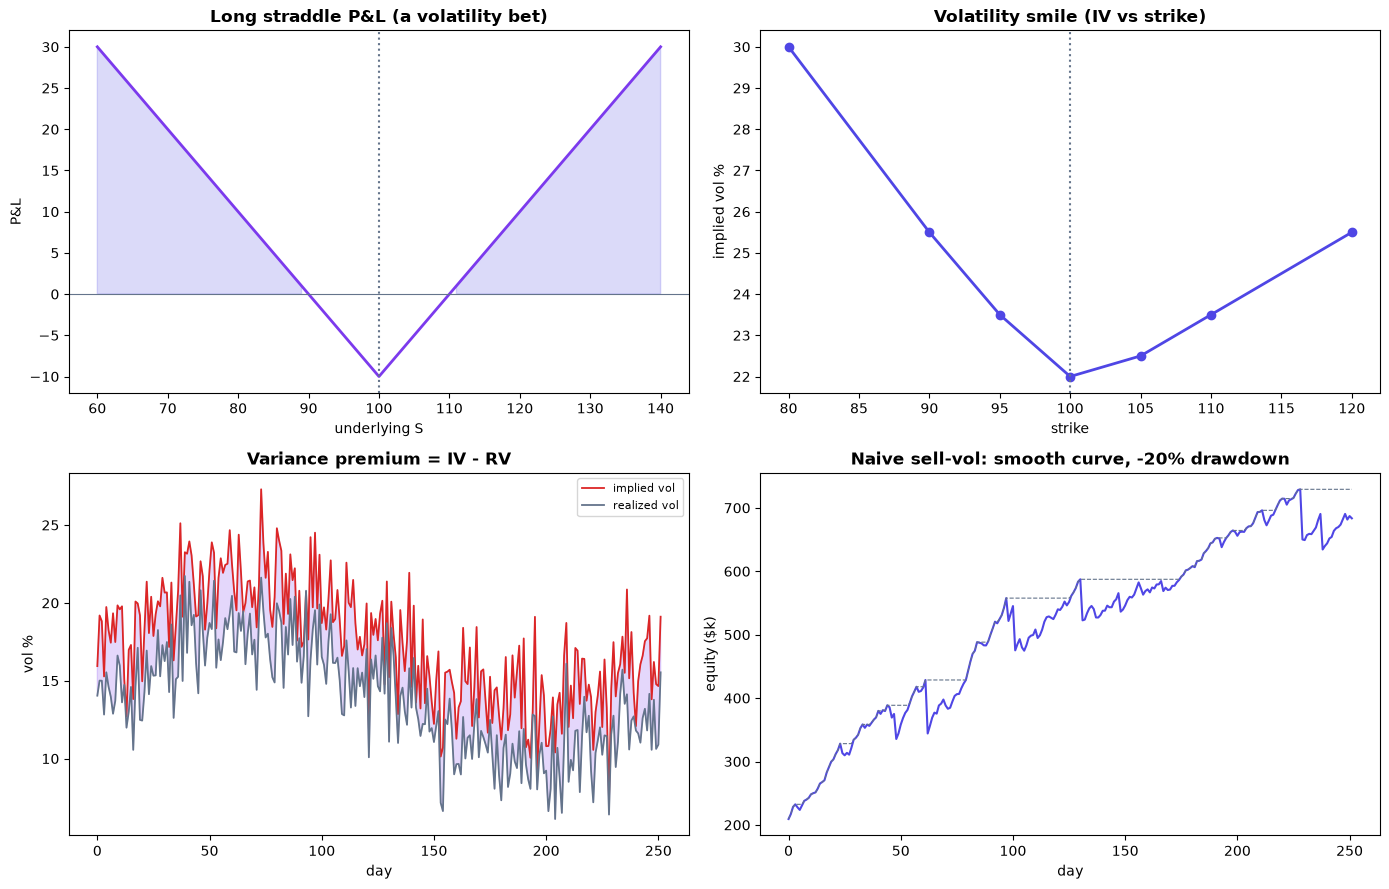

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
IND="#4f46e5"; VIO="#7c3aed"; RD="#dc2626"; GR="#64748b"

# (1) straddle P&L
ax[0,0].plot(S, straddle_pnl, color=VIO, lw=2)
ax[0,0].axhline(0, color=GR, lw=0.8); ax[0,0].axvline(X, color=GR, ls=":")
ax[0,0].fill_between(S, straddle_pnl, 0, where=straddle_pnl>0, color=IND, alpha=0.2)
ax[0,0].set_title("Long straddle P&L (a volatility bet)", fontweight="bold")
ax[0,0].set_xlabel("underlying S"); ax[0,0].set_ylabel("P&L")

# (2) the smile
ax[0,1].plot(strikes, smile_iv*100, "o-", color=IND, lw=2)
ax[0,1].axvline(100, color=GR, ls=":")
ax[0,1].set_title("Volatility smile (IV vs strike)", fontweight="bold")
ax[0,1].set_xlabel("strike"); ax[0,1].set_ylabel("implied vol %")

# (3) variance premium: IV vs RV
ax[1,0].plot(implied*100, color=RD, lw=1.3, label="implied vol")
ax[1,0].plot(realized*100, color=GR, lw=1.3, label="realized vol")
ax[1,0].fill_between(range(days), implied*100, realized*100, where=implied>realized,
                     color=VIO, alpha=0.2)
ax[1,0].set_title("Variance premium = IV - RV", fontweight="bold")
ax[1,0].set_xlabel("day"); ax[1,0].set_ylabel("vol %"); ax[1,0].legend(fontsize=8)

# (4) naive short-straddle equity with drawdown
ax[1,1].plot(equity/1e3, color=IND, lw=1.5)
ax[1,1].plot(peak/1e3, color=GR, lw=0.8, ls="--")
ax[1,1].set_title(f"Naive sell-vol: smooth curve, {maxdd:.0%} drawdown", fontweight="bold")
ax[1,1].set_xlabel("day"); ax[1,1].set_ylabel("equity ($k)")

plt.tight_layout(); plt.savefig("chart_1_vol.png", dpi=115, bbox_inches="tight")
print("saved chart_1_vol.png")

## The one-paragraph version

You find option edge two ways: a **model** that scores the market every day (scalable) or an **event**
strategy that fires on earnings/rates (rare). You don't need 90% accuracy — a **t-stat of 1** (≈55%),
repeated, is enough. Two forces fight you: **adverse selection** (the profitable limit orders never
fill; the losers fill easily, so a perfect backtest underperforms live) and **costs** (bid-ask + fees
turn a Sharpe-1.45 strategy into a negative CAGR). The reason to trade options at all is **volatility**:
Sharpe's quote says you can forecast *standard deviation* but not *returns*, so trade the bumpiness, not
the direction — that's what a **straddle** (ATM call + put) does. Volatility obeys three laws: it's
**negatively correlated to index returns** (≈ −0.7), it has **vol-of-vol** (high vol → big vol moves,
≈ +0.8), and it's **mean-reverting** (unlike trending price). There is no single **implied vol** — it's
backed out of the option price (vs **historical vol** from returns) and varies by strike (the **smile**)
and expiry (term structure). The payday is the **variance premium**: implied vol almost always exceeds
realized vol because options are **insurance**, so selling vol harvests IV − RV — largest, surprisingly,
in **low-VIX** regimes. But selling a straddle every day looks smooth and hides a **catastrophic tail**,
so you harvest the premium *selectively, with defined risk, net of costs*. OTS-3 to OTS-6 turn all of
this into pricing models, Greeks, forecasts, hedges, and backtests.